In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/SKRIPSI_Septidiana'

# Pastikan direktori ada
import os
os.makedirs(DRIVE_PATH, exist_ok=True)

# Definisikan path untuk data mentah setelah scraping
RAW_DATA_PATH = f'{DRIVE_PATH}/hasil_tiktok_comments_roblox.csv'

print(f"Direktori Google Drive: {DRIVE_PATH}")
print(f"Path Data Mentah: {RAW_DATA_PATH}")

Direktori Google Drive: /content/drive/MyDrive/SKRIPSI_Septidiana
Path Data Mentah: /content/drive/MyDrive/SKRIPSI_Septidiana/hasil_tiktok_comments_roblox.csv


In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/SKRIPSI_Septidiana'

# Pastikan direktori ada
import os
os.makedirs(DRIVE_PATH, exist_ok=True)

# Definisikan path untuk data mentah (sumber 1 dan sumber 2)
RAW_DATA_SOURCE_1 = f'{DRIVE_PATH}/hasil_tiktok_comments_roblox_part1.csv'
RAW_DATA_SOURCE_2 = f'{DRIVE_PATH}/hasil_tiktok_comments_roblox_part2.csv'

# Path untuk data gabungan yang akan digunakan oleh proses selanjutnya
RAW_DATA_PATH = f'{DRIVE_PATH}/hasil_tiktok_comments_roblox.csv' # This will be the combined output

print(f"Direktori Google Drive: {DRIVE_PATH}")
print(f"Path Data Sumber 1: {RAW_DATA_SOURCE_1}")
print(f"Path Data Sumber 2: {RAW_DATA_SOURCE_2}")
print(f"Path Data Gabungan (Output): {RAW_DATA_PATH}")

Direktori Google Drive: /content/drive/MyDrive/SKRIPSI_Septidiana
Path Data Sumber 1: /content/drive/MyDrive/SKRIPSI_Septidiana/hasil_tiktok_comments_roblox_part1.csv
Path Data Sumber 2: /content/drive/MyDrive/SKRIPSI_Septidiana/hasil_tiktok_comments_roblox_part2.csv
Path Data Gabungan (Output): /content/drive/MyDrive/SKRIPSI_Septidiana/hasil_tiktok_comments_roblox.csv


install library

In [ ]:
# apify-client : untuk menjalankan Actor dan mengambil dataset dari Apif
# pandas : untuk mengolah data dan menyimpan CSV/Excel
# openpyxi : engine untuk membuat file Excel •xlsx
# tqam : membuat progress bar di loop
# rich : membuat tampilan output terminal lebih cantik (tabel, warna)

!pip install apify-client pandas openpyxl tqdm rich

from apify_client import ApifyClient
from tqdm import tqdm
from rich.console import Console
from rich.table import Table
from rich import box
import pandas as pd
# Console rich digunakan untuk menampilkan teks berwarna & tabel
console = Console()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.4/146.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 28.1 MB/s eta 0:00:00


### Loading and Combining Datasets from Google Drive

As requested, the TikTok comments scraping process has been separated. This notebook will now directly load two existing datasets (assuming `hasil_tiktok_comments_roblox_part1.csv` and `hasil_tiktok_comments_roblox_part2.csv`) from your Google Drive, combine them, and save the merged data into a single CSV file (`hasil_tiktok_comments_roblox.csv`) for subsequent preprocessing steps.

In [ ]:
import pandas as pd
import os
from rich.console import Console
from rich.table import Table
from rich import box

console = Console()

console.rule("[bold yellow] Memuat & Menggabungkan Dataset dari Google Drive")

# Pastikan file sumber ada sebelum memuat
if not os.path.exists(RAW_DATA_SOURCE_1):
    console.print(f"[bold red]Error: File tidak ditemukan: {RAW_DATA_SOURCE_1}")
    # Buat DataFrame kosong atau tangani error sesuai kebutuhan
    df_part1 = pd.DataFrame()
else:
    df_part1 = pd.read_csv(RAW_DATA_SOURCE_1)
    console.print(f"[green]Data dari {os.path.basename(RAW_DATA_SOURCE_1)} berhasil dimuat. ({len(df_part1)} baris)")

if not os.path.exists(RAW_DATA_SOURCE_2):
    console.print(f"[bold red]Error: File tidak ditemukan: {RAW_DATA_SOURCE_2}")
    df_part2 = pd.DataFrame()
else:
    df_part2 = pd.read_csv(RAW_DATA_SOURCE_2)
    console.print(f"[green]Data dari {os.path.basename(RAW_DATA_SOURCE_2)} berhasil dimuat. ({len(df_part2)} baris)")

# Gabungkan kedua DataFrame
# Gunakan ignore_index=True agar indeks tidak tumpang tindih
df_combined = pd.concat([df_part1, df_part2], ignore_index=True)

# Simpan DataFrame gabungan ke RAW_DATA_PATH
df_combined.to_csv(RAW_DATA_PATH, index=False, encoding='utf-8-sig')

console.print(f"[bold green] Kedua dataset berhasil digabungkan dan disimpan di: {RAW_DATA_PATH} ({len(df_combined)} baris total)")

# Membuat tabel ringkasan menggunakan rich
table = Table(title="Ringkasan Output Gabungan", box=box.HEAVY)
table.add_column("Deskripsi", style="cyan", justify="center")
table.add_column("Nilai", style="green")

table.add_row("File Sumber 1", os.path.basename(RAW_DATA_SOURCE_1))
table.add_row("Jumlah Baris Sumber 1", str(len(df_part1)))
table.add_row("File Sumber 2", os.path.basename(RAW_DATA_SOURCE_2))
table.add_row("Jumlah Baris Sumber 2", str(len(df_part2)))
table.add_row("File Gabungan", os.path.basename(RAW_DATA_PATH))
table.add_row("Jumlah Baris Gabungan", str(len(df_combined)))

console.print(table)

print("\n=== Contoh 5 Baris Pertama Data Gabungan ===")
display(df_combined.head(5))

────────────────────────────────  Memuat & Menggabungkan Dataset dari Google Drive ────────────────────────────────

Data dari hasil_tiktok_comments_roblox_part1.csv berhasil dimuat. (3320 baris)

Data dari hasil_tiktok_comments_roblox_part2.csv berhasil dimuat. (4000 baris)

 Kedua dataset berhasil digabungkan dan disimpan di: 
/content/drive/MyDrive/SKRIPSI_Septidiana/hasil_tiktok_comments_roblox.csv (7320 baris total)

                    Ringkasan Output Gabungan                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃       Deskripsi       ┃ Nilai                                  ┃
┣━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃     File Sumber 1     ┃ hasil_tiktok_comments_roblox_part1.csv ┃
┃ Jumlah Baris Sumber 1 ┃ 3320                                   ┃
┃     File Sumber 2     ┃ hasil_tiktok_comments_roblox_part2.csv ┃
┃ Jumlah Baris Sumber 2 ┃ 4000                                   ┃
┃     File Gabungan     ┃ hasil_tiktok_comments_roblox.csv       ┃
┃ Jumlah Baris Gabungan ┃ 7320                                   ┃
┗━━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


=== Contoh 5 Baris Pertama Data Gabungan ===


,videoWebUrl,submittedVideoUrl,input,cid,createTime,createTimeISO,text,diggCount,likedByAuthor,pinnedByAuthor,repliesToId,replyCommentTotal,uid,uniqueId,avatarThumbnail,mentions,detailedMentions,error,errorCode,url
0,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.586611e+18,1.766395e+09,2025-12-22T09:24:03.000Z,aku kena scam tadi.... 😕,84.0,True,False,NaN,20.0,7.555458e+18,dewdew141,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN
1,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.597419e+18,1.768912e+09,2026-01-20T12:27:51.000Z,gua juga kena scam sama dia😭😭,0.0,False,False,NaN,0.0,6.939359e+18,liiiii__7,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN
2,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.582433e+18,1.765423e+09,2025-12-11T03:13:17.000Z,"barusan kenaaa, sakittt bngtt☹️☹️",24.0,True,False,NaN,12.0,6.588751e+18,princcesrra,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN
3,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.578009e+18,1.764393e+09,2025-11-29T05:04:34.000Z,silakan silaturahmi hehe,22.0,True,False,NaN,33.0,7.523087e+18,urns20,https://p19-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN
4,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.596142e+18,1.768615e+09,2026-01-17T01:52:50.000Z,nitip nama akun musang 🙏,9.0,False,False,NaN,36.0,7.193930e+18,yannn_1515,https://p19-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN


Preprocessing Data

1. Cleaning Data

In [ ]:
import pandas as pd
import re

pd.set_option('display.max_columns', None)

# Load data mentah dari Google Drive
my_df = pd.read_csv(RAW_DATA_PATH)

# Pastikan kolom 'text' ada dan rename menjadi 'content'
if 'text' in my_df.columns:
    my_df = my_df.rename(columns={'text': 'content'})
else:
    print("Kolom 'text' tidak ditemukan. Harap periksa struktur data.")
    # Lakukan penanganan error atau keluar jika kolom kunci tidak ada

print("=== SEBELUM CLEANING ===")
print(f"Jumlah data          : {len(my_df)}")
print(f"Missing value content: {my_df['content'].isnull().sum()}")

# 1. Menghapus baris dengan content null atau string kosong
my_df.dropna(subset=['content'], inplace=True)
my_df = my_df[my_df['content'].str.strip() != '']

# 2. Menghapus duplikat berdasarkan kolom content
jumlah_sebelum = len(my_df)
my_df.drop_duplicates(subset=['content'], inplace=True)
jumlah_duplikat = jumlah_sebelum - len(my_df)
print(f"\nJumlah duplikat yang dihapus : {jumlah_duplikat}")

# 3. Membersihkan isi teks ulasan
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)          # hapus URL
    text = re.sub(r'[@#$%^&*]', '', text)                 # hapus simbol @, #, $, %, dll
    text = re.sub(r'[^\w\s]', '', text)                  # hapus tanda baca (.,!? dll)
    text = re.sub(r'\d+', '', text)                       # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()              # hapus spasi berlebih
    return text

my_df['content'] = my_df['content'].apply(clean_text)

# 4. Hapus baris yang jadi kosong setelah cleaning
my_df = my_df[my_df['content'].str.strip() != '']

print("\n=== HASIL CLEANING ===")
print(f"Jumlah data setelah cleaning : {len(my_df)}")
print(f"Missing value content        : {my_df['content'].isnull().sum()}")
print()
print("Contoh hasil cleaning:")
display(my_df[['content']].head(10))

# Simpan hasil cleaning ke Google Drive
CLEANING_PATH = f'{DRIVE_PATH}/3_cleaned_data.csv'
my_df.to_csv(CLEANING_PATH, index=False)
print(f"Hasil cleaning disimpan di: {CLEANING_PATH}")

=== SEBELUM CLEANING ===
Jumlah data          : 7320
Missing value content: 87

Jumlah duplikat yang dihapus : 870

=== HASIL CLEANING ===
Jumlah data setelah cleaning : 6180
Missing value content        : 0

Contoh hasil cleaning:


,content
0,aku kena scam tadi
1,gua juga kena scam sama dia
2,barusan kenaaa sakittt bngtt
3,silakan silaturahmi hehe
4,nitip nama akun musang
5,kejadiannya sama kek gua disuruh first eh dike...
6,aku baru kena scam
7,ka barusan kena tadi
8,barusan kena scam ilang majaa guaa
9,gua kena scam scrit hilang Semoga ALLAH berika...


Hasil cleaning disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/3_cleaned_data.csv


2. Case Folding

In [ ]:
import pandas as pd

# Muat data hasil cleaning
CLEANING_PATH = f'{DRIVE_PATH}/3_cleaned_data.csv'
my_df = pd.read_csv(CLEANING_PATH)

# Case Folding: hanya mengubah huruf besar menjadi huruf kecil
my_df['text_clean'] = my_df['content'].str.lower()

print("=== HASIL CASE FOLDING ===")
print(f"Jumlah data : {len(my_df)}")
print()
display(my_df[['content', 'text_clean']].head(10))

# Simpan hasil case folding ke Google Drive
CASEFOLDING_PATH = f'{DRIVE_PATH}/4_case_folding_data.csv'
my_df.to_csv(CASEFOLDING_PATH, index=False)
print(f"Hasil case folding disimpan di: {CASEFOLDING_PATH}")

=== HASIL CASE FOLDING ===
Jumlah data : 6180



,content,text_clean
0,aku kena scam tadi,aku kena scam tadi
1,gua juga kena scam sama dia,gua juga kena scam sama dia
2,barusan kenaaa sakittt bngtt,barusan kenaaa sakittt bngtt
3,silakan silaturahmi hehe,silakan silaturahmi hehe
4,nitip nama akun musang,nitip nama akun musang
5,kejadiannya sama kek gua disuruh first eh dike...,kejadiannya sama kek gua disuruh first eh dike...
6,aku baru kena scam,aku baru kena scam
7,ka barusan kena tadi,ka barusan kena tadi
8,barusan kena scam ilang majaa guaa,barusan kena scam ilang majaa guaa
9,gua kena scam scrit hilang Semoga ALLAH berika...,gua kena scam scrit hilang semoga allah berika...


Hasil case folding disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/4_case_folding_data.csv


3. Tokenizing

In [ ]:
import pandas as pd
import nltk
# Ensure the 'punkt' and 'punkt_tab' tokenizer models are downloaded, forcing a re-download if necessary
nltk.download('punkt', force=True, quiet=False)
nltk.download('punkt_tab', force=True, quiet=False) # Added to download the missing resource
from nltk.tokenize import word_tokenize

# Muat data hasil case folding
# This path is correct for tokenizing after case folding based on user's desired order.
CASEFOLDING_PATH = f'{DRIVE_PATH}/4_case_folding_data.csv'
my_df = pd.read_csv(CASEFOLDING_PATH)

# Ensure the column used for tokenizing is 'text_clean', as it comes from case folding.
my_df['text_tokens'] = my_df['text_clean'].apply(lambda x: word_tokenize(x))

print("=== HASIL TOKENIZING ===")
print(f"Jumlah data : {len(my_df)}")
print()
# Display the correct columns based on input and output
display(my_df[['text_clean', 'text_tokens']].head(10))

# Simpan hasil tokenizing ke Google Drive
TOKENIZING_PATH = f'{DRIVE_PATH}/5_tokenizing_data.csv'
my_df.to_csv(TOKENIZING_PATH, index=False)
print(f"Hasil tokenizing disimpan di: {TOKENIZING_PATH}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


=== HASIL TOKENIZING ===
Jumlah data : 6180



,text_clean,text_tokens
0,aku kena scam tadi,"[aku, kena, scam, tadi]"
1,gua juga kena scam sama dia,"[gua, juga, kena, scam, sama, dia]"
2,barusan kenaaa sakittt bngtt,"[barusan, kenaaa, sakittt, bngtt]"
3,silakan silaturahmi hehe,"[silakan, silaturahmi, hehe]"
4,nitip nama akun musang,"[nitip, nama, akun, musang]"
5,kejadiannya sama kek gua disuruh first eh dike...,"[kejadiannya, sama, kek, gua, disuruh, first, ..."
6,aku baru kena scam,"[aku, baru, kena, scam]"
7,ka barusan kena tadi,"[ka, barusan, kena, tadi]"
8,barusan kena scam ilang majaa guaa,"[barusan, kena, scam, ilang, majaa, guaa]"
9,gua kena scam scrit hilang semoga allah berika...,"[gua, kena, scam, scrit, hilang, semoga, allah..."


Hasil tokenizing disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/5_tokenizing_data.csv


4. Normalisasi

In [ ]:
import pandas as pd
import re
import ast

TOKENIZING_PATH = f'{DRIVE_PATH}/5_tokenizing_data.csv'
my_df = pd.read_csv(TOKENIZING_PATH)

# Ubah kembali kolom text_tokens dari string CSV ke list Python
my_df['text_tokens'] = my_df['text_tokens'].apply(ast.literal_eval)

def remove_repeated_chars(token):
    return re.sub(r'(.)\1+', r'\1', str(token))

# Normalisasi diterapkan per-token (bukan ke string list utuh)
my_df['text_normalized'] = my_df['text_tokens'].apply(
    lambda tokens: [remove_repeated_chars(t) for t in tokens]
)

print("=== HASIL NORMALISASI (Repeated Characters) ===")
print(f"Jumlah data : {len(my_df)}")
print()
display(my_df[['text_tokens', 'text_normalized']].head(10))

NORMALIZATION_OUTPUT_PATH = f'{DRIVE_PATH}/6_normalization_data.csv'
my_df.to_csv(NORMALIZATION_OUTPUT_PATH, index=False)
print(f"Hasil normalisasi disimpan di: {NORMALIZATION_OUTPUT_PATH}")

=== HASIL NORMALISASI (Repeated Characters) ===
Jumlah data : 6180



,text_tokens,text_normalized
0,"[aku, kena, scam, tadi]","[aku, kena, scam, tadi]"
1,"[gua, juga, kena, scam, sama, dia]","[gua, juga, kena, scam, sama, dia]"
2,"[barusan, kenaaa, sakittt, bngtt]","[barusan, kena, sakit, bngt]"
3,"[silakan, silaturahmi, hehe]","[silakan, silaturahmi, hehe]"
4,"[nitip, nama, akun, musang]","[nitip, nama, akun, musang]"
5,"[kejadiannya, sama, kek, gua, disuruh, first, ...","[kejadianya, sama, kek, gua, disuruh, first, e..."
6,"[aku, baru, kena, scam]","[aku, baru, kena, scam]"
7,"[ka, barusan, kena, tadi]","[ka, barusan, kena, tadi]"
8,"[barusan, kena, scam, ilang, majaa, guaa]","[barusan, kena, scam, ilang, maja, gua]"
9,"[gua, kena, scam, scrit, hilang, semoga, allah...","[gua, kena, scam, scrit, hilang, semoga, alah,..."


Hasil normalisasi disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/6_normalization_data.csv


5. Stopwords Removal

In [ ]:
import pandas as pd
import ast
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

NORMALIZATION_OUTPUT_PATH = f'{DRIVE_PATH}/6_normalization_data.csv'
my_df = pd.read_csv(NORMALIZATION_OUTPUT_PATH)

# Ubah kembali kolom text_normalized dari string CSV ke list Python
my_df['text_normalized'] = my_df['text_normalized'].apply(ast.literal_eval)

stop = stopwords.words('indonesian')

my_df['text_StopWord'] = my_df['text_normalized'].apply(
    lambda tokens: [t for t in tokens if t not in stop]
)

print("=== HASIL STOPWORD REMOVAL ===")
print(f"Jumlah data : {len(my_df)}")
print()
display(my_df[['text_normalized', 'text_StopWord']].head(10))

STOPWORD_PATH = f'{DRIVE_PATH}/7_stopword_data.csv'
my_df.to_csv(STOPWORD_PATH, index=False)
print(f"Hasil stopword removal disimpan di: {STOPWORD_PATH}")

=== HASIL STOPWORD REMOVAL ===
Jumlah data : 6180



,text_normalized,text_StopWord
0,"[aku, kena, scam, tadi]","[kena, scam]"
1,"[gua, juga, kena, scam, sama, dia]","[gua, kena, scam]"
2,"[barusan, kena, sakit, bngt]","[barusan, kena, sakit, bngt]"
3,"[silakan, silaturahmi, hehe]","[silakan, silaturahmi, hehe]"
4,"[nitip, nama, akun, musang]","[nitip, nama, akun, musang]"
5,"[kejadianya, sama, kek, gua, disuruh, first, e...","[kejadianya, kek, gua, disuruh, first, eh, dik..."
6,"[aku, baru, kena, scam]","[kena, scam]"
7,"[ka, barusan, kena, tadi]","[ka, barusan, kena]"
8,"[barusan, kena, scam, ilang, maja, gua]","[barusan, kena, scam, ilang, maja, gua]"
9,"[gua, kena, scam, scrit, hilang, semoga, alah,...","[gua, kena, scam, scrit, hilang, semoga, alah,..."


Hasil stopword removal disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/7_stopword_data.csv


6. Stemming

In [ ]:
!pip install Sastrawi
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Muat data hasil stopwords
STOPWORD_PATH = f'{DRIVE_PATH}/7_stopword_data.csv'
my_df = pd.read_csv(STOPWORD_PATH)

# Kolom text_tokens dibaca sebagai string, perlu diubah ke list lagi
# Gunakan ast.literal_eval untuk mengonversi string representasi list menjadi list Python
import ast
my_df['text_StopWord'] = my_df['text_StopWord'].apply(ast.literal_eval)

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmed_wrapper(term):
    return stemmer.stem(term)

# Buat dictionary untuk menyimpan hasil stemming agar tidak melakukan stemming ulang pada kata yang sama
term_dict = {}
for document in my_df['text_StopWord']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)

def get_stemmed_term(document):
    return [term_dict[term] for term in document]

my_df['text_stemindo'] = my_df['text_StopWord'].apply(lambda x: ' '.join(get_stemmed_term(x)))

print("=== HASIL STEMMING ===")
print(f"Jumlah data        : {len(my_df)}")
print(f"Jumlah unique term : {len(term_dict)}")
print()
display(my_df[['text_StopWord', 'text_stemindo']].head(10))

# Simpan hasil stemming ke Google Drive
STEMMING_PATH = f'{DRIVE_PATH}/7_stemming_data.csv'
my_df.to_csv(STEMMING_PATH, index=False)
print(f"Hasil stemming disimpan di: {STEMMING_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.5 MB/s eta 0:00:00
=== HASIL STEMMING ===
Jumlah data        : 6180
Jumlah unique term : 7775



,text_StopWord,text_stemindo
0,"[kena, scam]",kena scam
1,"[gua, kena, scam]",gua kena scam
2,"[barusan, kena, sakit, bngt]",barusan kena sakit bngt
3,"[silakan, silaturahmi, hehe]",sila silaturahmi hehe
4,"[nitip, nama, akun, musang]",nitip nama akun musang
5,"[kejadianya, kek, gua, disuruh, first, eh, dik...",kejadianya kek gua suruh first eh dikeluarin b...
6,"[kena, scam]",kena scam
7,"[ka, barusan, kena]",ka barusan kena
8,"[barusan, kena, scam, ilang, maja, gua]",barusan kena scam ilang maja gua
9,"[gua, kena, scam, scrit, hilang, semoga, alah,...",gua kena scam scrit hilang moga alah ganti nya...


Hasil stemming disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/7_stemming_data.csv


Data Labeling

In [ ]:
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Muat data hasil stemming
STEMMING_PATH = f'{DRIVE_PATH}/7_stemming_data.csv'
my_df = pd.read_csv(STEMMING_PATH)

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Kata negasi
kata_negasi_raw = ['tidak', 'kurang', 'belum', 'gak', 'ga', 'nggak', 'ngga', 'tak', 'bukan', 'jangan', 'bukanlah']
kata_negasi = [stemmer.stem(word) for word in kata_negasi_raw]

def stem_frasa(frasa):
    return ' '.join(stemmer.stem(w) for w in frasa.split())

# ======================================================================
# FRASA (dicek di teks utuh SEBELUM di-split per kata)
# ======================================================================
frasa_positif_raw = [
    'luar biasa', 'mantap jiwa', 'the best', 'ok banget', 'suka banget',
    'puas banget', 'top markotop', 'kualitas bagus', 'fitur keren',
    'keren banget', 'senang sekali', 'bagus banget', 'aman banget',
    'baik baik saja', 'gak masalah', 'tidak masalah', 'salut sama',
    'respect banget', 'untung besar', 'bagus sih', 'positif sih',
]
frasa_negatif_raw = [
    'hilang robux', 'uang hilang', 'akun hilang', 'aset hilang', 'item hilang',
    'bikin rugi', 'bug parah', 'rusak parah', 'lemot banget', 'jelek banget',
    'buruk banget', 'tidak bisa', 'gak bisa', 'bikin emosi', 'buang buang waktu',
    'penipuan robux', 'rugi robux', 'akun dihack', 'password bocor', 'data bocor',
    'privasi terancam', 'keamanan buruk', 'server down', 'force close', 'tidak stabil',
    'lupa waktu',
    # Reaksi khas terhadap isu sosial (anak diculik, kekerasan, pelecehan, kecanduan)
    'miris banget', 'serem banget', 'ngeri banget', 'kasian banget', 'sedih banget',
    'bahaya banget', 'hati hati banget', 'awasi anak', 'jaga anak', 'orang tua harus',
    'korban penculikan', 'korban pelecehan', 'predator anak', 'rawan pelecehan',
    'jangan biarkan anak', 'salah didik', 'gara gara roblox', 'kurang pengawasan',
    'anak di bawah umur', 'menjaga anak',
]
frasa_positif = [stem_frasa(f) for f in frasa_positif_raw]
frasa_negatif = [stem_frasa(f) for f in frasa_negatif_raw]

# ======================================================================
# KATA (single-word, dicek per token)
# ======================================================================
kata_positif_raw = [
    # Umum/review
    'bagus', 'baik', 'mantap', 'keren', 'suka', 'senang', 'puas', 'membantu',
    'mudah', 'nyaman', 'canggih', 'hebat', 'top', 'menarik', 'cepat', 'lancar',
    'memuaskan', 'terbaik', 'sempurna', 'berguna', 'bermanfaat', 'responsif',
    'recommended', 'rekomen', 'oke', 'ok', 'kece', 'seru', 'asik', 'asyik',
    'menyenangkan', 'komunitas', 'teman', 'interaksi', 'kreatif', 'edukatif',
    'aman', 'terpercaya', 'amazing', 'recommend', 'cinta', 'memukau', 'fantastis',
    'good', 'nice', 'gokil', 'inovatif', 'luarbiasa', 'beruntung', 'santai',
    'sip', 'bener', 'betul', 'setuju', 'gemes', 'lucu',
    # Reaksi positif/apresiatif terhadap isu sosial (dukungan, kelegaan, rasa syukur)
    'syukur', 'alhamdulillah', 'untung', 'selamat', 'lega', 'tenang', 'bijak',
    'peduli', 'sadar', 'bertanggungjawab', 'berhasil', 'aman', 'terlindungi',
    'positif', 'bermanfaat', 'edukasi', 'belajar', 'bakat', 'produktif', 'hiburan',
]
kata_negatif_raw = [
    # Umum/review
    'buruk', 'jelek', 'lambat', 'lemot', 'error', 'bug', 'crash', 'susah',
    'sulit', 'kecewa', 'gagal', 'mengecewakan', 'parah', 'payah', 'sampah',
    'boros', 'gangguan', 'rusak', 'berbayar', 'mahal', 'iklan', 'spam',
    'ribet', 'membingungkan', 'zonk', 'bohong', 'tipu', 'scam', 'penipuan',
    'dibohongi', 'rugi', 'hack', 'curang', 'kehilangan', 'dimaling', 'dicuri',
    'candu', 'kecanduan', 'ketagihan', 'berlebihan', 'konflik', 'bertengkar',
    'toxic', 'bullying', 'dibully', 'perkelahian', 'berantem', 'masalah',
    'ketipu', 'banned', 'diban', 'blokir', 'sensor', 'phishing', 'virus',
    'gila', 'sialan', 'basi', 'males', 'bosen', 'ngeselin', 'nyebelin', 'anjir',
    'penipu', 'ngaco', 'gabisa', 'ngelag', 'cheat', 'exploiter', 'warning',
    'bahaya', 'bermasalah', 'lag', 'tertipu', 'menjengkelkan',
    # Reaksi khas isu sosial: kekhawatiran, kengerian, kritik ke orang tua/platform
    'miris', 'serem', 'ngeri', 'kasian', 'kasihan', 'prihatin', 'sedih', 'takut',
    'trauma', 'shock', 'was-was', 'waspada', 'rawan', 'korban', 'culik', 'diculik',
    'penculikan', 'pelecehan', 'kekerasan', 'predator', 'modus', 'jebak', 'dijebak',
    'dirugikan', 'eksploitasi', 'kacau', 'astaga', 'yaallah', 'duh', 'aduh',
    'goblok', 'tolol', 'bego', 'bodoh', 'risih', 'jijik', 'nyesek', 'baper',
    'emosi', 'kzl', 'kesel', 'bete', 'ngeselin', 'lalai', 'cuek', 'abai',
]
kata_positif = [stemmer.stem(w) for w in sorted(set(kata_positif_raw))]
kata_negatif = [stemmer.stem(w) for w in sorted(set(kata_negatif_raw))]

def hitung_skor_frasa(teks, daftar_frasa):
    return sum(teks.count(frasa) for frasa in daftar_frasa)

def pelabelan_teks(teks):
    if pd.isna(teks) or str(teks).strip() == '':
        return None
    teks = str(teks)
    words = teks.split()
    skor_positif = 0
    skor_negatif = 0

    # 1. Cek frasa (multi-kata) di teks utuh
    skor_positif += hitung_skor_frasa(teks, frasa_positif)
    skor_negatif += hitung_skor_frasa(teks, frasa_negatif)

    # 2. Cek kata per token, dengan penanganan negasi
    for i, word in enumerate(words):
        ada_negasi = (i > 0 and words[i-1] in kata_negasi)
        if word in kata_positif:
            skor_negatif += 1 if ada_negasi else 0
            skor_positif += 0 if ada_negasi else 1
        elif word in kata_negatif:
            skor_positif += 1 if ada_negasi else 0
            skor_negatif += 0 if ada_negasi else 1

    if skor_positif > skor_negatif:
        return 'Positif'
    elif skor_negatif > skor_positif:
        return 'Negatif'
    else:
        return 'Netral'

if 'text_stemindo' not in my_df.columns:
    print("Kolom 'text_stemindo' tidak ditemukan di DataFrame. Harap periksa data.")
else:
    my_df['Label'] = my_df['text_stemindo'].apply(pelabelan_teks)

print("=== HASIL LABELLING ===")
print(my_df['Label'].value_counts())
print(f"\nTotal data berlabel : {my_df['Label'].notna().sum()}")
print(f"Data tanpa label    : {my_df['Label'].isna().sum()}")
print()
display(my_df.head(10))

my_df.dropna(subset=['Label'], inplace=True)

LABELLING_OUTPUT_PATH = f'{DRIVE_PATH}/8_labelled_data.csv'
my_df.to_csv(LABELLING_OUTPUT_PATH, index=False)
print(f"Hasil labelling disimpan di: {LABELLING_OUTPUT_PATH}")

=== HASIL LABELLING ===
Label
Netral     4287
Negatif    1108
Positif     699
Name: count, dtype: int64

Total data berlabel : 6094
Data tanpa label    : 86



,videoWebUrl,submittedVideoUrl,input,cid,createTime,createTimeISO,content,diggCount,likedByAuthor,pinnedByAuthor,repliesToId,replyCommentTotal,uid,uniqueId,avatarThumbnail,mentions,detailedMentions,error,errorCode,url,text_clean,text_tokens,text_normalized,text_StopWord,text_stemindo,Label
0,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.586611e+18,1.766395e+09,2025-12-22T09:24:03.000Z,aku kena scam tadi,84.0,True,False,NaN,20.0,7.555458e+18,dewdew141,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN,aku kena scam tadi,"['aku', 'kena', 'scam', 'tadi']","['aku', 'kena', 'scam', 'tadi']","['kena', 'scam']",kena scam,Negatif
1,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.597419e+18,1.768912e+09,2026-01-20T12:27:51.000Z,gua juga kena scam sama dia,0.0,False,False,NaN,0.0,6.939359e+18,liiiii__7,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN,gua juga kena scam sama dia,"['gua', 'juga', 'kena', 'scam', 'sama', 'dia']","['gua', 'juga', 'kena', 'scam', 'sama', 'dia']","['gua', 'kena', 'scam']",gua kena scam,Negatif
2,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.582433e+18,1.765423e+09,2025-12-11T03:13:17.000Z,barusan kenaaa sakittt bngtt,24.0,True,False,NaN,12.0,6.588751e+18,princcesrra,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN,barusan kenaaa sakittt bngtt,"['barusan', 'kenaaa', 'sakittt', 'bngtt']","['barusan', 'kena', 'sakit', 'bngt']","['barusan', 'kena', 'sakit', 'bngt']",barusan kena sakit bngt,Netral
3,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.578009e+18,1.764393e+09,2025-11-29T05:04:34.000Z,silakan silaturahmi hehe,22.0,True,False,NaN,33.0,7.523087e+18,urns20,https://p19-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN,silakan silaturahmi hehe,"['silakan', 'silaturahmi', 'hehe']","['silakan', 'silaturahmi', 'hehe']","['silakan', 'silaturahmi', 'hehe']",sila silaturahmi hehe,Netral
4,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.596142e+18,1.768615e+09,2026-01-17T01:52:50.000Z,nitip nama akun musang,9.0,False,False,NaN,36.0,7.193930e+18,yannn_1515,https://p19-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN,nitip nama akun musang,"['nitip', 'nama', 'akun', 'musang']","['nitip', 'nama', 'akun', 'musang']","['nitip', 'nama', 'akun', 'musang']",nitip nama akun musang,Netral
5,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.582564e+18,1.765453e+09,2025-12-11T11:39:56.000Z,kejadiannya sama kek gua disuruh first eh dike...,39.0,True,False,NaN,18.0,7.343241e+18,satria13217,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN,kejadiannya sama kek gua disuruh first eh dike...,"['kejadiannya', 'sama', 'kek', 'gua', 'disuruh...","['kejadianya', 'sama', 'kek', 'gua', 'disuruh'...","['kejadianya', 'kek', 'gua', 'disuruh', 'first...",kejadianya kek gua suruh first eh dikeluarin b...,Negatif
6,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.com/@urns20/video/757800823...,7.587298e+18,1.766555e+09,2025-12-24T05:50:10.000Z,aku baru kena scam,8.0,False,False,NaN,4.0,7.573217e+18,axel.mahesa.gunawan,https://p16-common-sign.tiktokcdn-us.com/tos-a...,[],[],NaN,NaN,NaN,aku baru kena scam,"['aku', 'baru', 'kena', 'scam']","['aku', 'baru', 'kena', 'scam']","['kena', 'scam']",kena scam,Negatif
7,https://www.tiktok.com/@urns20/video/757800823...,https://www.tiktok.co

Hasil labelling disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/8_labelled_data.csv


Distribusi Label Sentimen

=== DISTRIBUSI LABEL SENTIMEN ===
Label
Netral     4287
Negatif    1108
Positif     699
Name: count, dtype: int64

Total data : 6094


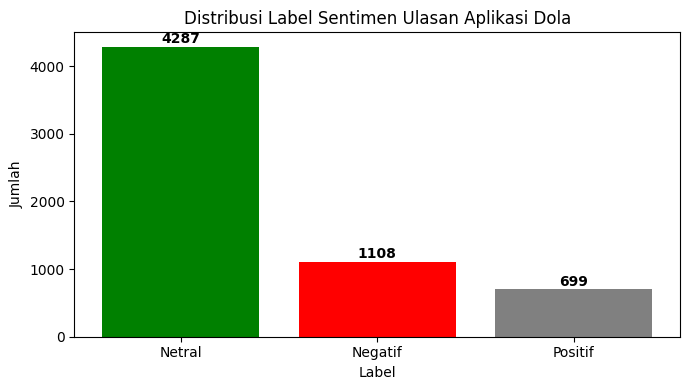

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Memuat data berlabel yang sudah disimpan
LABELLING_OUTPUT_PATH = f'{DRIVE_PATH}/8_labelled_data.csv'
data_clean = pd.read_csv(LABELLING_OUTPUT_PATH)

sentimen_count = data_clean['Label'].value_counts()

print("=== DISTRIBUSI LABEL SENTIMEN ===")
print(sentimen_count)
print(f"\nTotal data : {len(data_clean)}")

plt.figure(figsize=(7, 4))
bars = plt.bar(sentimen_count.index, sentimen_count.values, color=['green', 'red', 'gray'])
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.title('Distribusi Label Sentimen Ulasan Aplikasi Dola')
for bar, val in zip(bars, sentimen_count.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

Pembobotan TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = data_clean['text_stemindo'].fillna('')
y = data_clean['Label']

tfidf_vectorizer = TfidfVectorizer(max_features=4000) # Mengurangi jumlah fitur menjadi 4000
X_tfidf = tfidf_vectorizer.fit_transform(X)

print("=== HASIL TF-IDF ===")
print(f"Ukuran matriks fitur : {X_tfidf.shape}")
print(f"Jumlah fitur vocab   : {len(tfidf_vectorizer.vocabulary_)}")

=== HASIL TF-IDF ===
Ukuran matriks fitur : (6094, 4000)
Jumlah fitur vocab   : 4000


Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== HASIL SPLITTING DATA (80:20) ===")
print(f"Total data          : {X_tfidf.shape[0]}")
print(f"Jumlah Data Train   : {X_train.shape[0]} ({X_train.shape[0]/X_tfidf.shape[0]*100:.0f}%)")
print(f"Jumlah Data Test    : {X_test.shape[0]} ({X_test.shape[0]/X_tfidf.shape[0]*100:.0f}%)")
print()
print("Distribusi label data train:")
print(y_train.value_counts())
print()
print("Distribusi label data test:")
print(y_test.value_counts())
print()

n_features = X_tfidf.shape[1]
ratio = X_train.shape[0] / n_features
print("=== ANALISIS SPLITTING ===")
print(f"Jumlah fitur (vocab size) : {n_features}")
print(f"Rasio data train/fitur    : {ratio:.4f}")
if ratio < 1:
    print("Indikasi : Berisiko UNDERFITTING — data train lebih sedikit dari jumlah fitur.")
    print("Saran    : Tambah data atau kurangi fitur (misal: batasi max_features TF-IDF).")
elif ratio < 5:
    print("Indikasi : Data train cukup namun perlu diperhatikan kompleksitas model.")
else:
    print("Indikasi : Data train cukup representatif, risiko underfitting rendah.")

=== HASIL SPLITTING DATA (80:20) ===
Total data          : 6094
Jumlah Data Train   : 4875 (80%)
Jumlah Data Test    : 1219 (20%)

Distribusi label data train:
Label
Netral     3430
Negatif     886
Positif     559
Name: count, dtype: int64

Distribusi label data test:
Label
Netral     857
Negatif    222
Positif    140
Name: count, dtype: int64

=== ANALISIS SPLITTING ===
Jumlah fitur (vocab size) : 4000
Rasio data train/fitur    : 1.2188
Indikasi : Data train cukup namun perlu diperhatikan kompleksitas model.


Training SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("=== HASIL TRAINING SVM (80:20) ===")
print("Model SVM dengan kernel linear berhasil dilatih.")
print(f"Jumlah data train : {X_train.shape[0]}")
print(f"Jumlah data test  : {X_test.shape[0]}")

=== HASIL TRAINING SVM (80:20) ===
Model SVM dengan kernel linear berhasil dilatih.
Jumlah data train : 4875
Jumlah data test  : 1219


Training Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Inisialisasi dan latih model Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== HASIL TRAINING NAIVE BAYES (80:20) ===")
print("Model Naive Bayes berhasil dilatih.")
print(f"Jumlah data train : {X_train.shape[0]}")
print(f"Jumlah data test  : {X_test.shape[0]}")

=== HASIL TRAINING NAIVE BAYES (80:20) ===
Model Naive Bayes berhasil dilatih.
Jumlah data train : 4875
Jumlah data test  : 1219


Clasification Report SVM dan Naive Bayes

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("=== HASIL EVALUASI SVM (80:20) ===")
accuracy_svm = accuracy_score(y_test, y_pred)
print(f"Akurasi SVM : {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)") # Fixed syntax error
print("\n=== CLASSIFICATION REPORT SVM (80:20) ===")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Netral', 'Positif']))

if 'y_pred_nb' in locals(): # Pastikan y_pred_nb sudah terdefinisi
    print("\n=== HASIL EVALUASI NAIVE BAYES (80:20) ===")
    accuracy_nb = accuracy_score(y_test, y_pred_nb)
    print(f"Akurasi Naive Bayes : {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)") # Fixed syntax error
    print("\n=== CLASSIFICATION REPORT NAIVE BAYES (80:20) ===")
    print(classification_report(y_test, y_pred_nb, target_names=['Negatif', 'Netral', 'Positif']))
else:
    print("\nModel Naive Bayes belum dilatih atau variabel y_pred_nb tidak ditemukan.")

=== HASIL EVALUASI SVM (80:20) ===
Akurasi SVM : 0.9336 (93.36%)

=== CLASSIFICATION REPORT SVM (80:20) ===
              precision    recall  f1-score   support

     Negatif       0.95      0.81      0.88       222
      Netral       0.93      0.99      0.96       857
     Positif       0.93      0.80      0.86       140

    accuracy                           0.93      1219
   macro avg       0.94      0.87      0.90      1219
weighted avg       0.93      0.93      0.93      1219


=== HASIL EVALUASI NAIVE BAYES (80:20) ===
Akurasi Naive Bayes : 0.7769 (77.69%)

=== CLASSIFICATION REPORT NAIVE BAYES (80:20) ===
              precision    recall  f1-score   support

     Negatif       0.96      0.36      0.52       222
      Netral       0.76      0.99      0.86       857
     Positif       0.88      0.11      0.19       140

    accuracy                           0.78      1219
   macro avg       0.87      0.49      0.53      1219
weighted avg       0.81      0.78      0.72      121

Confusion Matrix

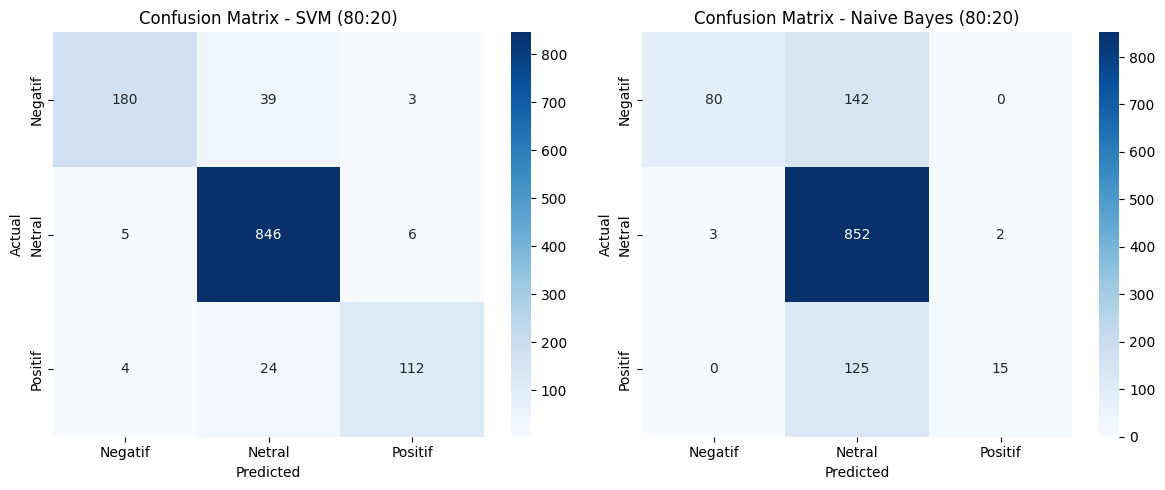

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Confusion Matrix for SVM
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
cm_svm = confusion_matrix(y_test, y_pred, labels=['Negatif', 'Netral', 'Positif'])
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM (80:20)')

# Confusion Matrix for Naive Bayes
if 'y_pred_nb' in locals(): # Pastikan y_pred_nb sudah terdefinisi
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    cm_nb = confusion_matrix(y_test, y_pred_nb, labels=['Negatif', 'Netral', 'Positif'])
    sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negatif', 'Netral', 'Positif'],
                yticklabels=['Negatif', 'Netral', 'Positif'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Naive Bayes (80:20)')
else:
    print("\nTidak dapat menampilkan Confusion Matrix untuk Naive Bayes karena model belum dilatih.")

plt.tight_layout()
plt.show()

ROC dan AUC

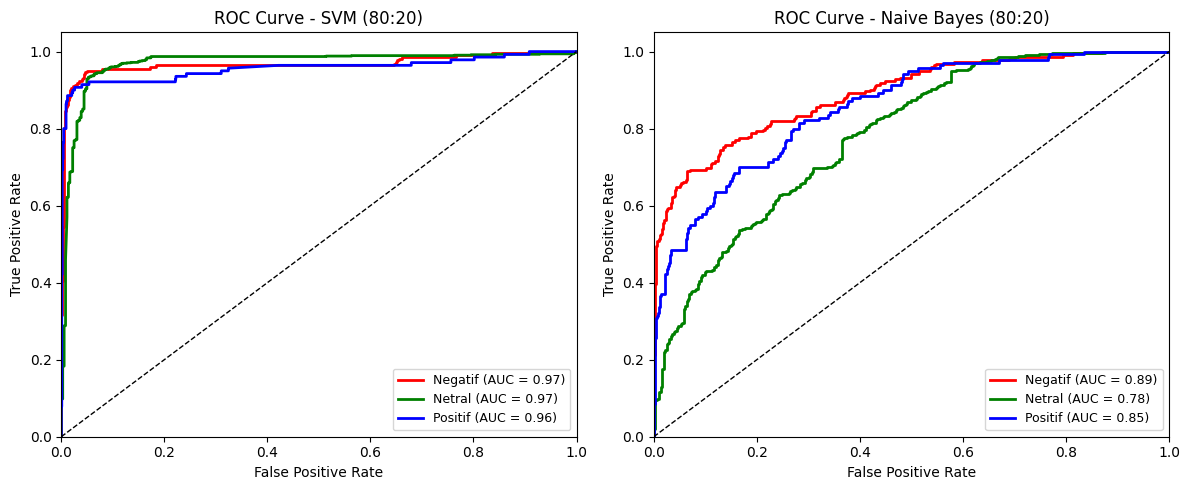

=== NILAI AUC PER KELAS ===
Kelas     AUC SVM     AUC Naive Bayes
Negatif   0.9669      0.8893
Netral    0.9699      0.7827
Positif   0.9560      0.8550

=== RATA-RATA AUC (MACRO) ===
AUC SVM (macro)         : 0.9643
AUC Naive Bayes (macro) : 0.8423


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Label kelas yang digunakan (urutan harus konsisten)
classes = ['Negatif', 'Netral', 'Positif']
n_classes = len(classes)

# Binarisasi label aktual (one-vs-rest) untuk perhitungan ROC multi-kelas
y_test_bin = label_binarize(y_test, classes=classes)

# Skor SVM menggunakan decision_function (SVC belum diaktifkan probability=True)
y_score_svm = svm_model.decision_function(X_test)

# Skor Naive Bayes menggunakan predict_proba
y_score_nb = nb_model.predict_proba(X_test)

def compute_roc_auc(y_true_bin, y_score, classes):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Micro-average (menggabungkan seluruh kelas)
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    # Macro-average (rata-rata AUC tiap kelas)
    roc_auc["macro"] = np.mean([roc_auc[i] for i in range(len(classes))])
    return fpr, tpr, roc_auc

fpr_svm, tpr_svm, auc_svm = compute_roc_auc(y_test_bin, y_score_svm, classes)
fpr_nb, tpr_nb, auc_nb = compute_roc_auc(y_test_bin, y_score_nb, classes)

colors = ['red', 'green', 'blue']

plt.figure(figsize=(12, 5))

# ROC Curve - SVM
plt.subplot(1, 2, 1)
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_svm[i], tpr_svm[i], color=color, lw=2,
             label=f'{classes[i]} (AUC = {auc_svm[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM (80:20)')
plt.legend(loc='lower right', fontsize=9)

# ROC Curve - Naive Bayes
plt.subplot(1, 2, 2)
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_nb[i], tpr_nb[i], color=color, lw=2,
             label=f'{classes[i]} (AUC = {auc_nb[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes (80:20)')
plt.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("=== NILAI AUC PER KELAS ===")
print(f"{'Kelas':<10}{'AUC SVM':<12}{'AUC Naive Bayes'}")
for i, label in enumerate(classes):
    print(f"{label:<10}{auc_svm[i]:<12.4f}{auc_nb[i]:.4f}")

print("\n=== RATA-RATA AUC (MACRO) ===")
print(f"AUC SVM (macro)         : {auc_svm['macro']:.4f}")
print(f"AUC Naive Bayes (macro) : {auc_nb['macro']:.4f}")

Simpan model ke Google Drive

In [ ]:
import joblib, os

# Path untuk menyimpan model dan vectorizer
MODEL_DIR_SVM = f'{DRIVE_PATH}/model_svm_8020'
MODEL_DIR_NAIVE_BAYES = f'{DRIVE_PATH}/model_naive_bayes_8020'

os.makedirs(MODEL_DIR_SVM, exist_ok=True)
os.makedirs(MODEL_DIR_NAIVE_BAYES, exist_ok=True)

# Simpan model SVM dan TF-IDF vectorizer
joblib.dump(svm_model, f'{MODEL_DIR_SVM}/svm_model.joblib')
joblib.dump(tfidf_vectorizer, f'{MODEL_DIR_SVM}/tfidf_vectorizer_for_svm.joblib') # Simpan juga untuk konteks SVM
print(f"Model SVM (80:20) dan TF-IDF disimpan di: {MODEL_DIR_SVM}")

# Simpan model Naive Bayes jika sudah dilatih
if 'nb_model' in locals():
    joblib.dump(nb_model, f'{MODEL_DIR_NAIVE_BAYES}/naive_bayes_model.joblib')
    # TF-IDF vectorizer yang sama bisa digunakan, tapi simpan salinannya untuk setiap model jika perlu
    joblib.dump(tfidf_vectorizer, f'{MODEL_DIR_NAIVE_BAYES}/tfidf_vectorizer_for_nb.joblib')
    print(f"Model Naive Bayes (80:20) dan TF-IDF disimpan di: {MODEL_DIR_NAIVE_BAYES}")
else:
    print("Model Naive Bayes belum dilatih, tidak ada yang disimpan.")

Model SVM (80:20) dan TF-IDF disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/model_svm_8020
Model Naive Bayes (80:20) dan TF-IDF disimpan di: /content/drive/MyDrive/SKRIPSI_Septidiana/model_naive_bayes_8020
